# Territorial analysis: ECB Rate Shock and SME Failures

## Objective
Did failures rise more after the July 2022 hike in economically fragile (ZFRR) departments? Failures exist by sector nationally *or* by department for all firms, never crossed, so this is a separate department-level difference-in-differences on **annual non-overlapping** data (~100 departments, far better powered than the nine-sector analysis).

**ZFRR coding (Observatoire des Territoires legend):** 1 = FRR beneficiary, 2/3 = partial, 4 = FRR socle, 5 = FRR+. Treatment intensity = share of a department's communes classified FRR socle or + (codes 4–5).

In [1]:
from pathlib import Path
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ValueWarning
from IPython.display import display

warnings.simplefilter('ignore', ValueWarning)
sys.path.insert(0, str(Path().resolve().parent))
from src.data_loader import (load_failures_by_department, load_frr_communes,
                             load_firm_counts_by_department)
from src import cleaning

Path('../outputs').mkdir(exist_ok=True)
Path('../data/processed').mkdir(exist_ok=True)

fd = load_failures_by_department()
frr = load_frr_communes()
intensity = cleaning.zfrr_intensity_by_department(frr)
monthly = cleaning.build_dept_panel(fd, intensity)   # for visualisation
annual = cleaning.annualize(monthly, 'dept')          # for estimation
d = annual[annual['in_sample']].copy()
d['ly'] = np.log1p(d['failures'])
print('annual obs:', len(d), '| departments:', d['dept'].nunique(),
      '| years:', sorted(d['year'].unique()))

annual obs: 808 | departments: 101 | years: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2023), np.int32(2024), np.int32(2025)]


## 1. ZFRR intensity and treatment split
Departments split at the median share of communes classified FRR.

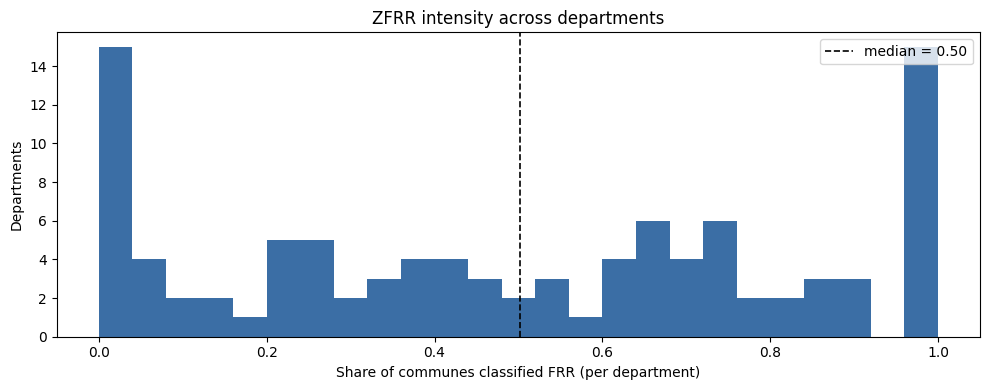

control: 50 | treated: 51


In [2]:
med = intensity.median()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(intensity, bins=25, color='#3b6ea5')
ax.axvline(med, color='black', ls='--', lw=1.2, label=f'median = {med:.2f}')
ax.set_xlabel('Share of communes classified FRR (per department)')
ax.set_ylabel('Departments')
ax.set_title('ZFRR intensity across departments')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/zfrr_intensity.png', dpi=150, bbox_inches='tight')
plt.show()
sp = d.groupby('treated')['dept'].nunique()
print('control:', int(sp.get(0, 0)), '| treated:', int(sp.get(1, 0)))

## 2. Monthly view (visualisation only)

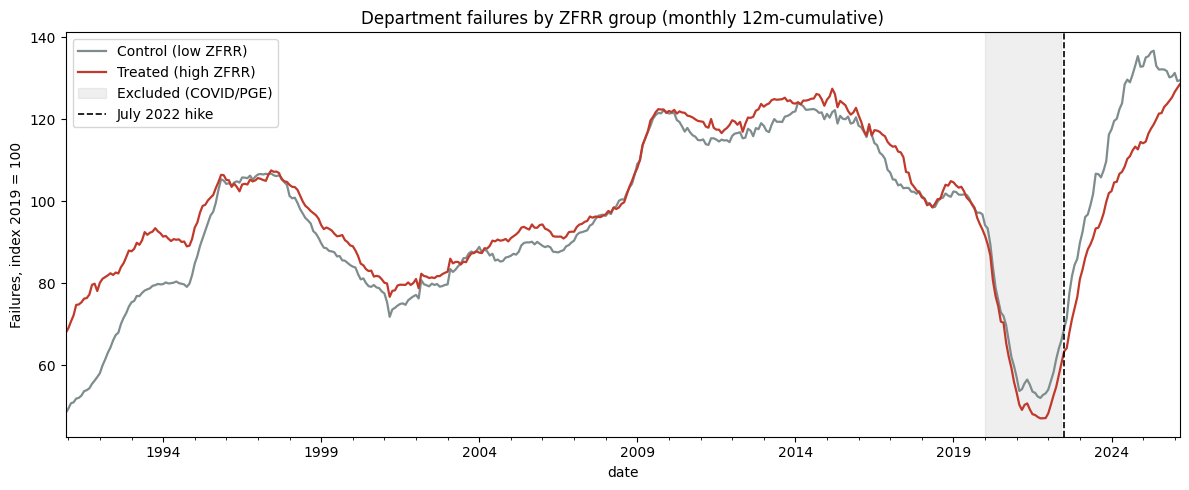

In [3]:
pos = monthly[monthly['failures'] > 0].copy()
base2019 = pos[pos['date'].dt.year == 2019].groupby('dept')['failures'].mean()
pos['idx'] = pos['failures'] / pos['dept'].map(base2019) * 100
grp = (pos.groupby([pos['date'], 'treated'])['idx'].mean()
       .unstack().rename(columns={1: 'Treated (high ZFRR)', 0: 'Control (low ZFRR)'}))
fig, ax = plt.subplots(figsize=(12, 5))
grp.plot(ax=ax, color={'Treated (high ZFRR)': '#c0392b', 'Control (low ZFRR)': '#7f8c8d'}, lw=1.6)
ax.axvspan(cleaning.COVID_START, cleaning.COVID_END, alpha=0.12, color='gray', label='Excluded (COVID/PGE)')
ax.axvline(cleaning.ECB_FIRST_HIKE, color='black', ls='--', lw=1.2, label='July 2022 hike')
ax.set_ylabel('Failures, index 2019 = 100')
ax.set_title('Department failures by ZFRR group (monthly 12m-cumulative)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/dept_panel_windows.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Difference-in-differences (annual)
Department fixed effects, standard errors clustered by department (~100 clusters).

In [4]:
m = smf.ols('ly ~ C(dept) + post + did', data=d).fit(
    cov_type='cluster', cov_kwds={'groups': d['dept']})
print(f"Binary DiD: {m.params['did']:+.4f} log ({np.expm1(m.params['did'])*100:+.1f}%), p={m.pvalues['did']:.3f}")

sd = d['zfrr_share'].std()
d['did_cont'] = d['post'] * d['zfrr_share']
mc = smf.ols('ly ~ C(dept) + post + did_cont', data=d).fit(
    cov_type='cluster', cov_kwds={'groups': d['dept']})
print(f"Continuous (per +1 SD of ZFRR share): {mc.params['did_cont']*sd:+.4f} log "
      f"({np.expm1(mc.params['did_cont']*sd)*100:+.1f}%), p={mc.pvalues['did_cont']:.3f}")

Binary DiD: -0.0842 log (-8.1%), p=0.034
Continuous (per +1 SD of ZFRR share): -0.0659 log (-6.4%), p=0.007


## 4. Event study (pre-trends)

Treatment-group deviation by year, relative to 2019. With ~100 departments and ~115 parameters (department + year fixed effects + interactions), cluster-robust covariance is rank-deficient, so heteroskedasticity-robust (HC1) standard errors are used here for indicative bands. Formal inference rests on the two-period DiD above. A flat pre-treatment profile would support parallel trends.

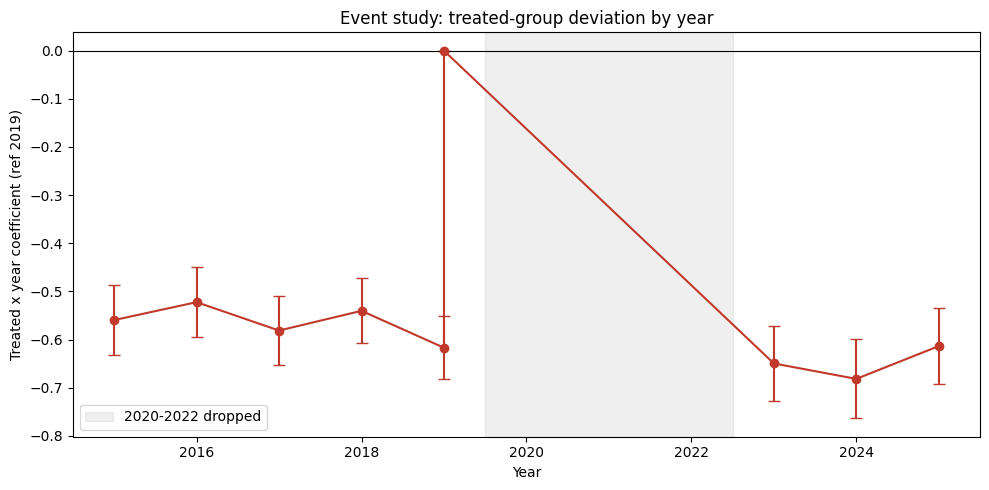

,year,coef,se
0,2015,-0.559,0.037
1,2016,-0.522,0.037
2,2017,-0.581,0.036
3,2018,-0.540,0.034
4,2019,-0.617,0.033
5,2019,0.000,0.000
6,2023,-0.650,0.040
7,2024,-0.682,0.042
8,2025,-0.614,0.040


In [5]:
es = smf.ols('ly ~ C(dept) + C(year, Treatment(reference=2019)) '
             '+ treated:C(year, Treatment(reference=2019))', data=d).fit(
    cov_type='HC1')
rows = []
for p in es.params.index:
    if p.startswith('treated:'):
        yr = int(p.rsplit('[', 1)[-1].rstrip(']').replace('T.', ''))
        rows.append((yr, es.params[p], es.bse[p]))
ev = pd.DataFrame(rows, columns=['year', 'coef', 'se'])
ev = pd.concat([ev, pd.DataFrame([{'year': 2019, 'coef': 0.0, 'se': 0.0}])], ignore_index=True)
ev = ev.sort_values('year').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(ev['year'], ev['coef'], yerr=1.96 * ev['se'], fmt='o-', color='#c0392b', capsize=4)
ax.axhline(0, color='black', lw=0.8)
ax.axvspan(2019.5, 2022.5, alpha=0.12, color='gray', label='2020-2022 dropped')
ax.set_xlabel('Year')
ax.set_ylabel('Treated x year coefficient (ref 2019)')
ax.set_title('Event study: treated-group deviation by year')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/dept_event_study.png', dpi=150, bbox_inches='tight')
plt.show()
display(ev.round(3))

## 5. Robustness
Three checks: weight by firm stock (effect on the average *firm*), broad FRR definition (codes 1–5), and metropolitan departments only (drop overseas).

In [6]:
firm = load_firm_counts_by_department()
dw = d.copy()
dw['fc'] = dw['dept'].map(firm)
dw = dw.dropna(subset=['fc'])
mw = smf.wls('ly ~ C(dept) + post + did', data=dw, weights=dw['fc']).fit(
    cov_type='cluster', cov_kwds={'groups': dw['dept']})
print(f"Weighted by firm stock (avg firm): {mw.params['did']:+.4f} log "
      f"({np.expm1(mw.params['did'])*100:+.1f}%), p={mw.pvalues['did']:.3f}")

inten_any = cleaning.zfrr_intensity_by_department(frr, col='frr_any')
da = cleaning.annualize(cleaning.build_dept_panel(fd, inten_any), 'dept')
da = da[da['in_sample']].copy(); da['ly'] = np.log1p(da['failures'])
mb = smf.ols('ly ~ C(dept) + post + did', data=da).fit(
    cov_type='cluster', cov_kwds={'groups': da['dept']})
print(f"Broad FRR (codes 1-5): {mb.params['did']:+.4f} log "
      f"({np.expm1(mb.params['did'])*100:+.1f}%), p={mb.pvalues['did']:.3f}")

dom = ['971', '972', '973', '974', '975', '976']
dm = d[~d['dept'].isin(dom)].copy()
mm = smf.ols('ly ~ C(dept) + post + did', data=dm).fit(
    cov_type='cluster', cov_kwds={'groups': dm['dept']})
print(f"Metropolitan only ({dm['dept'].nunique()} depts): {mm.params['did']:+.4f} log "
      f"({np.expm1(mm.params['did'])*100:+.1f}%), p={mm.pvalues['did']:.3f}")

Weighted by firm stock (avg firm): -0.0234 log (-2.3%), p=0.525
Broad FRR (codes 1-5): -0.0916 log (-8.8%), p=0.021
Metropolitan only (96 depts): -0.0426 log (-4.2%), p=0.100


## 6. Placebo: fake break in the baseline

In [7]:
b = annual[annual['in_baseline']].copy()
b['ly'] = np.log1p(b['failures'])
b['fake_post'] = (b['year'] >= 2018).astype(int)
b['fake_did'] = b['fake_post'] * b['treated']
mp = smf.ols('ly ~ C(dept) + fake_post + fake_did', data=b).fit(
    cov_type='cluster', cov_kwds={'groups': b['dept']})
print(f"Placebo DiD (fake 2018 break): {mp.params['fake_did']:+.4f} log, p={mp.pvalues['fake_did']:.3f}")

Placebo DiD (fake 2018 break): -0.0243 log, p=0.306


## 7. Descriptive: failure rate per 1,000 firms
Failures relative to the 2024 firm stock (fixed denominator), for interpretability.

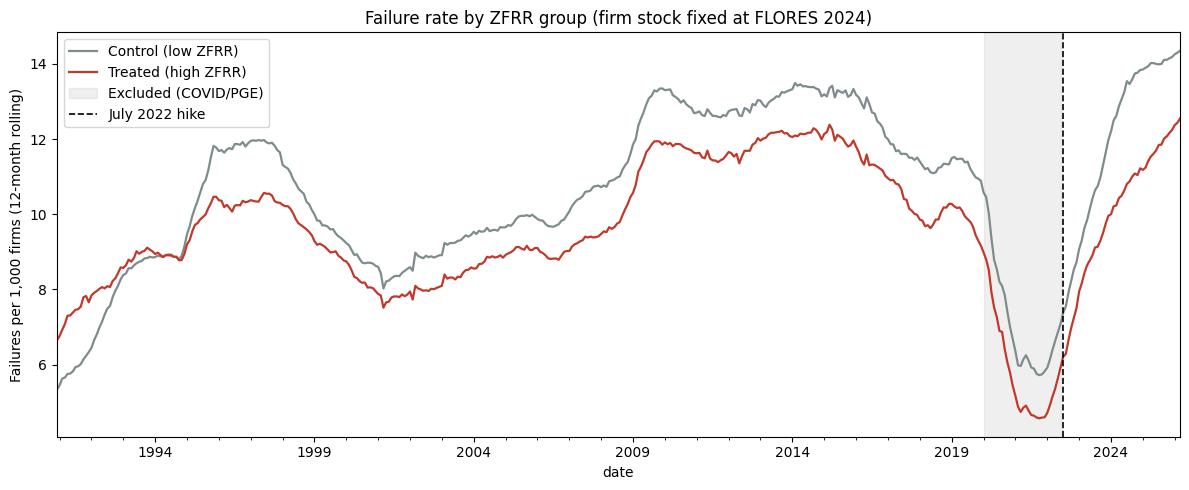

processed dept files written


In [8]:
r = monthly.copy()
r['fc'] = r['dept'].map(firm)
r = r[(r['fc'] > 0) & (r['failures'] > 0)]
r['rate'] = r['failures'] / r['fc'] * 1000
gr = (r.groupby([r['date'], 'treated'])['rate'].mean()
      .unstack().rename(columns={1: 'Treated (high ZFRR)', 0: 'Control (low ZFRR)'}))
fig, ax = plt.subplots(figsize=(12, 5))
gr.plot(ax=ax, color={'Treated (high ZFRR)': '#c0392b', 'Control (low ZFRR)': '#7f8c8d'}, lw=1.6)
ax.axvspan(cleaning.COVID_START, cleaning.COVID_END, alpha=0.12, color='gray', label='Excluded (COVID/PGE)')
ax.axvline(cleaning.ECB_FIRST_HIKE, color='black', ls='--', lw=1.2, label='July 2022 hike')
ax.set_ylabel('Failures per 1,000 firms (12-month rolling)')
ax.set_title('Failure rate by ZFRR group (firm stock fixed at FLORES 2024)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/dept_failure_rate.png', dpi=150, bbox_inches='tight')
plt.show()

annual.to_csv('../data/processed/dept_panel_annual.csv', index=False)
intensity.to_frame().to_csv('../data/processed/zfrr_intensity.csv')
print('processed dept files written')

## Results summary

The simple binary and continuous DiD are negative and significant: high-ZFRR (rural/fragile) departments saw a *smaller* post-2022 rise in failures, the opposite of the equity concern. **But the effect is not robust:** it loses significance when departments are weighted by their firm stock (effect on the average *firm*) and when overseas departments are dropped, and the event study shows the treated-control gap was already shifting before the hike. Taken together, there is **no robust evidence** that the rate shock disproportionately raised failures in fragile territories. The apparent effect is concentrated in small and overseas departments and fades under the robustness checks.

**Caveats:**
1. Department failures are all-firms (no PME breakdown at this level), but SMEs are ~99% of firms, so it is a close proxy.
2. ZFRR intensity is the share of communes classified, unweighted by population.
3. Firm stock (FLORES) is a 2024 snapshot used as a fixed weight/denominator.